# For the BrainHack course project - fMRI connectivity matrix mapping

In [117]:
#The sleepy group

In [5]:
!pip install nilearn

  Using cached nilearn-0.13.1-py3-none-any.whl.metadata (12 kB)
Using cached nilearn-0.13.1-py3-none-any.whl (10.6 MB)


In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nilearn import image, plotting
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets

In [97]:
from pathlib import Path
# Set this to path of where dataset is stored
dataset_root = Path("/Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-01")

func_file = dataset_root / "sub-01_task-rest_run-1_processed.nii.gz"

print("Using:", func_file)

Using: /Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-01/sub-01_task-rest_run-1_processed.nii.gz


In [110]:
#specifying which atlas to use (chose nilearn's for now - similar to tutorial has 39 ROIs)
atlas_dataset = datasets.fetch_atlas_msdl()
atlas_maps = image.load_img(atlas_dataset.maps)
atlas_labels = atlas_dataset.labels
atlas_masker = NiftiMapsMasker(maps_img=atlas_dataset, standardize=True)
print(atlas_maps.shape[-1])

[fetch_atlas_msdl] Dataset found in /Users/Gaithtry/nilearn_data/msdl_atlas

39


In [101]:
correlation_measure = ConnectivityMeasure(kind="correlation")

def compute_connectivity(func_file):
    fmri_img = image.load_img(func_file)
    matrix = correlation_measure.fit_transform([timeseries])[0]
    return matrix

In [103]:
def plot_connectivity_matrix(matrix, labels, title="Connectivity Matrix"):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [105]:
#running for one sample case:
subject_dir = subject_dirs[0]
subject_dir


PosixPath('/Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-01')

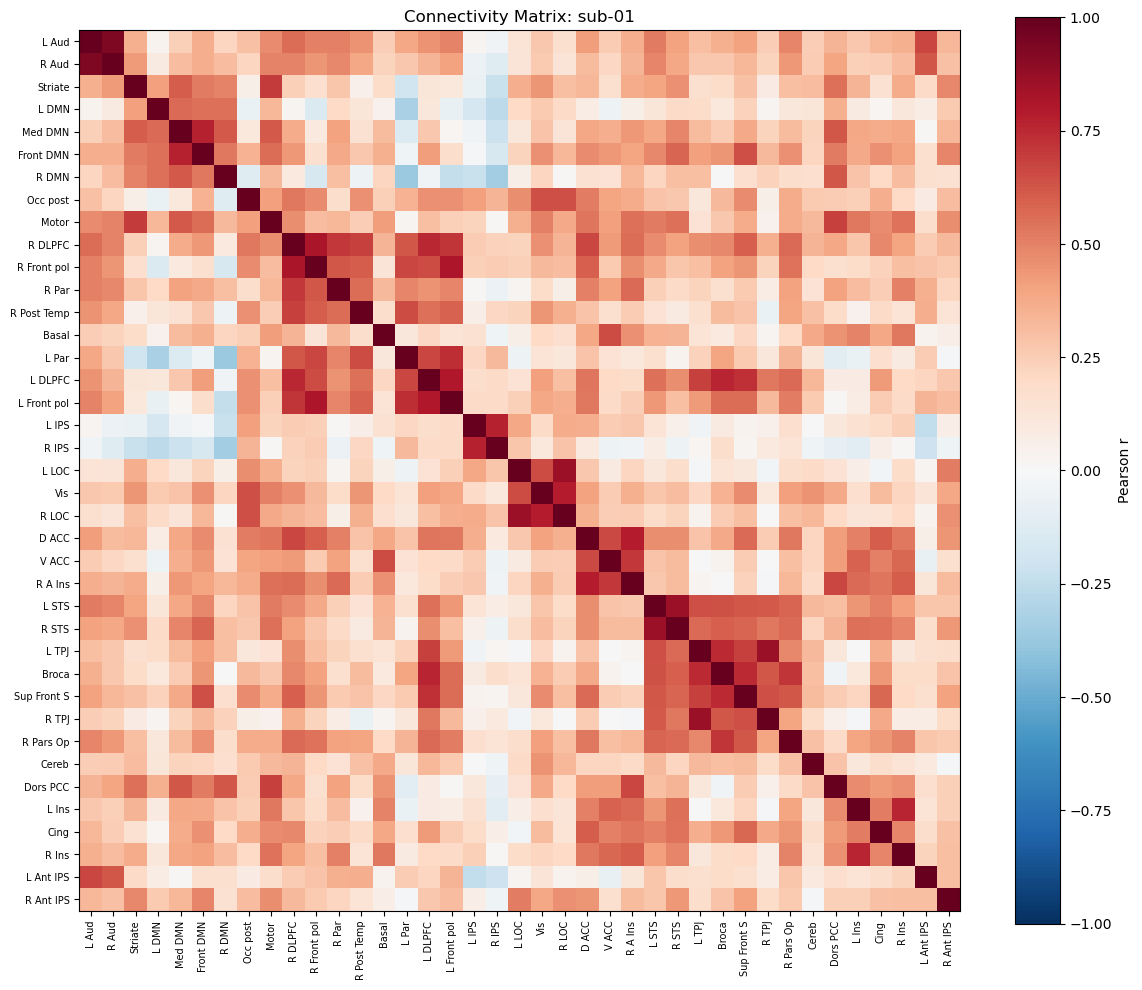

In [108]:
plot_connectivity_matrix(matrix, atlas_labels,
                         title=f"Connectivity Matrix: {subject_dir.name}")